In [1]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst
"""Spectrum 1D ON/OFF Analysis"""

'Spectrum 1D ON/OFF Analysis'

# Spectrum 1D ON/OFF Analysis with 1LHAASO Catalog


This notebook demonstrates how to:
1. Import necessary libraries and modules.
2. Load and select a source from the 1LHAASO catalog.
3. Configure an `AnalysisSpectrumConfig` object.
4. Perform spectrum analysis using `AnalysisSpectrum`.
5. Save and inspect the results, including flux points and fit results.

---


In [2]:
# Standard library imports
import astropy.units as u

# Third-party imports from gammapy
from gammapy.catalog import SourceCatalog1LHAASO
from gammapy.data import Observation
from gammapy.datasets import Datasets
from gammapy.utils.scripts import make_path
from gammapy.modeling.models import PowerLawSpectralModel, SkyModel, Models

# Third-party imports from regions
from regions import CircleSkyRegion

# feupy module imports
from feupy.utils.coordinates import convert_skycoord_to_dict
from feupy.analysis.config import CTAOAnalysisConfig
from feupy.analysis.core import CTAOAnalysis
from feupy.visualization.counts import show_hist_counts

from feupy.irf import (
CTAOVisibilityEstimator,
make_ctao_visibility_table,
)

### 1. Load and Select Source
In this section, we load the 1LHAASO catalog and select a specific source (1LHAASO J1219+2915) for analysis.

In [3]:
# Load the 1LHAASO catalog and select a source
catalog = SourceCatalog1LHAASO()
catalog.table

Source_Name,Model_a,RAJ2000,DECJ2000,pos_err,r39,r39_err,r39_ul,N0,N0_err,N0_ul,gamma,gamma_err,gamma_ul,E0,TS,TS100,Model_b,RAJ2000_b,DECJ2000_b,pos_err_b,r39_b,r39_err_b,r39_ul_b,N0_b,N0_err_b,N0_ul_b,gamma_b,gamma_err_b,gamma_ul_b,E0_b,TS_b,TS100_b,ASSO_Name,ASSO_Sep
,,deg,deg,deg,deg,deg,deg,1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),,,,TeV,,,,deg,deg,deg,deg,deg,deg,1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),,,,TeV,,,,deg
bytes20,bytes7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes16,float64
1LHAASO J0007+5659u,KM2A,1.86,57.0,0.12,--,--,0.18,3.3e-17,5e-18,--,3.1,0.2,--,50.0,86.5,43.6,WCDA,--,--,--,--,--,--,--,--,2.7000000000000002e-14,--,--,--,3.0,--,--,--,--
1LHAASO J0007+7303u,KM2A,1.91,73.07,0.07,0.17,0.03,--,3.41e-16,2.7e-17,--,3.4,0.12,--,50.0,361.0,171.6,WCDA,1.48,73.15,0.1,--,--,0.22,5.01e-13,1.1100000000000002e-13,--,2.74,0.11,--,3.0,141.6,--,CTA 1,0.12
1LHAASO J0056+6346u,KM2A,14.1,63.77,0.08,0.24,0.03,--,1.47e-16,1e-17,--,3.33,0.1,--,50.0,380.2,94.1,WCDA,13.78,63.96,0.15,0.33,0.07,--,1.45e-13,4.0999999999999996e-14,--,2.35,0.13,--,3.0,106.1,--,--,--
1LHAASO J0206+4302u,KM2A,31.7,43.05,0.13,--,--,0.27,2.4e-17,3e-18,--,2.62,0.16,--,50.0,96.0,82.8,WCDA,--,--,--,--,--,--,--,--,9e-15,--,--,--,3.0,--,--,--,--
1LHAASO J0212+4254u,KM2A,33.01,42.91,0.2,--,--,0.31,1.2e-17,3e-18,--,2.45,0.23,--,50.0,38.4,30.2,WCDA,--,--,--,--,--,--,--,--,7.000000000000001e-15,--,--,--,3.0,--,--,--,--
1LHAASO J0216+4237u,KM2A,34.1,42.63,0.1,--,--,0.13,1.8e-17,3e-18,--,2.58,0.17,--,50.0,102.0,65.6,WCDA,--,--,--,--,--,--,--,--,2.0000000000000003e-14,--,--,--,3.0,--,--,--,--
1LHAASO J0249+6022,KM2A,42.39,60.37,0.16,0.38,0.08,--,9.300000000000001e-17,9e-18,--,3.82,0.18,--,50.0,148.8,--,WCDA,41.52,60.49,0.4,0.71,0.1,--,1.96e-13,5.1000000000000004e-14,--,2.52,0.16,--,3.0,53.3,--,--,--
1LHAASO J0339+5307,KM2A,54.79,53.13,0.11,--,--,0.22,5.799999999999999e-17,6e-18,--,3.64,0.16,--,50.0,144.0,--,WCDA,--,--,--,--,--,--,--,--,2.1e-14,--,--,--,3.0,--,--,LHAASOJ0341+5258,0.37


In [4]:
source = catalog["1LHAASO J1219+2915"]

In [5]:
source.position

<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (184.98, 29.25)>

In [6]:
source.name

'1LHAASO J1219+2915'

In [7]:
source.sky_model()

SkyModel(spatial_model=<gammapy.modeling.models.spatial.PointSpatialModel object at 0x7410759829f0>, spectral_model=<gammapy.modeling.models.spectral.PowerLawSpectralModel object at 0x74107589d970>)temporal_model=None)

In [8]:
source.spectral_model("KM2A")

In [9]:
source.spectral_model("WCDA")

### Annual Visibility

In [14]:
year=2026

estimator = CTAOVisibilityEstimator(
    target=source.position,
    year=year,
    time_step_min=30,
)

df = make_ctao_visibility_table(estimator)

df

cta_north: 100%|██████████████████████████████| 365/365 [00:18<00:00, 19.93it/s]


,Observatory,Zenith (deg),Visibility (hours)
3,CTAO North,20,381.5
4,CTAO North,40,394.5
5,CTAO North,60,417.0
0,CTAO South,20,0.0
1,CTAO South,40,0.0
2,CTAO South,60,590.0


### 2. Configure `CTAOAnalysis`
Here, we configure the `CTAOAnalysisConfig` object with observation, dataset, and analysis settings for the spectrum analysis.

In [73]:
config = CTAOAnalysisConfig()

position = source.position.icrs

config.observation.obs_cone = convert_skycoord_to_dict(position)
config.observation.position_angle = 0 * u.deg
config.observation.offset = 0.5 * u.deg
config.observation.livetime = 50 * u.h
config.observation.required_irfs = ["South", "AverageAz", "40deg", "50h"]

config.datasets.map_selection = ["edisp", "background", "exposure"]

config.datasets.safe_mask.methods = ["aeff-default"]
config.datasets.safe_mask.parameters = {"aeff_percent": 10}

config.datasets.containment_correction = False
config.datasets.use_region_center = True

config.datasets.on_region = convert_skycoord_to_dict(position)
config.datasets.on_region.radius = 0.2 * u.deg

config.datasets.stack = False

config.datasets.on_off.acceptance = 1
config.datasets.on_off.acceptance_off = 5

config.datasets.geom.axes.energy.min = 30 * u.GeV
config.datasets.geom.axes.energy.max = 100 * u.TeV
config.datasets.geom.axes.energy.nbins = 15

config.datasets.geom.axes.energy_true.min = 3 * u.GeV
config.datasets.geom.axes.energy_true.max = 300 * u.TeV
config.datasets.geom.axes.energy_true.nbins = 20

config.flux_points.energy.min = 30 * u.GeV
config.flux_points.energy.max = 100 * u.TeV
config.flux_points.energy.nbins = 15
config.flux_points.source = "source"

config.sensitivity.gamma_min = 3
config.sensitivity.n_sigma = 2
config.sensitivity.bkg_syst_fraction = 0.05

config.statistics.n_obs = 1

DATA_PATH = make_path("./data/")
DATA_PATH.mkdir(parents=True, exist_ok=True)

config.sensitivity.data_path = DATA_PATH

print(config)

CTAOAnalysisConfig

    general:
        log: {level: info, filename: null, filemode: null, format: null, datefmt: null}
        outdir: .
        n_jobs: 1
        datasets_file: null
        models_file: null
    observation:
        obs_cone: {frame: icrs, lon: 184.97999684579457 deg, lat: 29.250002038380092 deg,
            radius: null}
        livetime: 50.0 h
        offset: 0.5 deg
        position_angle: 0.0 deg
        required_irfs: [South, AverageAz, 40deg, 50h]
    datasets:
        type: 1d
        stack: false
        geom:
            wcs:
                skydir: {frame: null, lon: null, lat: null}
                binsize: 0.02 deg
                width: {width: 5.0 deg, height: 5.0 deg}
                binsize_irf: 0.2 deg
            selection: {offset_max: 2.5 deg}
            axes:
                energy: {min: 30.0 GeV, max: 100.0 TeV, nbins: 15}
                energy_true: {min: 3.0 GeV, max: 300.0 TeV, nbins: 20}
        map_selection: [edisp, background, exposu

### 3. Running Spectrum Analysis
In this section, we create an instance of `CTAOAnalysis` and perform the spectrum analysis based on the configured settings. The process includes simulating observations, running fits, and extracting flux points.

In [74]:
# Create and run spectrum analysis
analysis = CTAOAnalysis(config)

# Simulate observation and spectrum
analysis.simulate_observation()

INFO:feupy.analysis.config:Setting logging config: {'level': 'INFO', 'filename': None, 'filemode': None, 'format': None, 'datefmt': None}
INFO:feupy.analysis.core:Observation 0 created


In [75]:
source.spectral_model("WCDA")

In [76]:
model_simu =  PowerLawSpectralModel(
    index=2.67,
    amplitude=3.4e-14 * u.Unit("cm-2 s-1 TeV-1"),
    reference=3* u.TeV,
)
model_source = SkyModel(spectral_model=model_simu, name="source")
analysis.get_spectrum_dataset(model_source)

In [77]:
print(analysis.spectrum_dataset)

SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 38674 
  Total background counts         : 29237.69
  Total excess counts             : 9436.31

  Predicted counts                : 38674.15
  Predicted background counts     : 29237.69
  Predicted excess counts         : 9436.46

  Exposure min                    : 5.39e+07 m2 s
  Exposure max                    : 6.28e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 15 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : -622830.27

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 2

  Component 0: SkyModel
  
    Name                      : source
    Datasets names            : None
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : 
    Temporal model type       : 
    Parameters:
      index                      

In [78]:
analysis.get_datasets()

In [79]:
print(analysis.datasets)

Datasets
--------

Dataset 0: 

  Type       : SpectrumDatasetOnOff
  Name       : obs-0
  Instrument : CTA
  Models     : 




In [80]:
analysis.datasets.info_table()

name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
obs-0,38704,9338.2,47.01590926166463,29365.799999999996,30922.16666666668,30922.16666666668,nan,53862348.78905563,628287109922.3849,180000.0,180000.0,0.21502222222222223,0.1631433333333333,0.05187888888888889,15,15,wstat,2850.654067173819,146829,15.0,75.0,0.19999999999999998


In [81]:
analysis.set_models(Models(model_source))

INFO:feupy.analysis.core:Reading model.
INFO:feupy.analysis.core:Models

Component 0: SkyModel

  Name                      : source
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : 
  Temporal model type       : 
  Parameters:
    index                         :      2.670   +/-    0.00             
    amplitude                     :   3.40e-14   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      3.000       TeV         




In [82]:
print(analysis.datasets)

Datasets
--------

Dataset 0: 

  Type       : SpectrumDatasetOnOff
  Name       : obs-0
  Instrument : CTA
  Models     : ['source']




In [83]:
analysis.get_file_name()

'sens_CTAO-South_40deg_50h_livetime50.0h'

In [84]:
analysis.run_fit()

In [85]:
analysis.fit_result.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.6422e+00,,1.735e-02,nan,nan,False,,
,amplitude,3.6131e-14,TeV-1 s-1 cm-2,1.535e-15,nan,nan,False,,
,reference,3.0000e+00,TeV,0.000e+00,nan,nan,True,,


In [86]:
analysis.get_flux_points()

In [87]:
analysis.flux_points

In [88]:
# Run the sensitivity analysis
analysis.compute_sensitivity()

# Write the sensitivity table to a file (CSV in this case)
analysis.write_table_sensitivity()

# Read the sensitivity table back if needed
sensitivity_table = analysis.read_table_sensitivity()

# Print the sensitivity table summary
print("\nSensitivity Table:")
print(sensitivity_table)

INFO:gammapy.estimators.points.core:Inferred format: gadf-sed
INFO:feupy.analysis.core:Table (sens_CTAO-South_40deg_50h_livetime50.0h.fits) stored to data.



Sensitivity Table:
      e_ref              e_min        ...     background      criterion  
       GeV                GeV         ...                                
------------------ ------------------ ... ------------------ ------------
 39.31429989764608 30.000000000000004 ...                2.0 significance
 67.51637695410695  51.52047254806851 ...             2612.4          bkg
115.94918818030368  88.47863638587606 ...            13705.6          bkg
199.12523222047227 151.94870523363537 ...  8160.200000000001          bkg
 341.9675353414204  260.9489698901356 ... 2663.2000000000003          bkg
 587.2776338962768  448.1404746557164 ... 1156.6000000000001 significance
1008.5607071749256  769.6136340726085 ...  538.8000000000001 significance
1732.0508075688779 1321.6952702285685 ... 225.60000000000002 significance
 2974.535869440405  2269.812162890764 ...               85.4 significance
5108.3164534916505  3898.059840916185 ... 36.800000000000004 significance
 8772.762586965462

In [89]:
table_sens = analysis.table_sens

<Axes: xlabel='Energy [$\\mathrm{GeV}$]', ylabel='Flux Sensitivity [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>

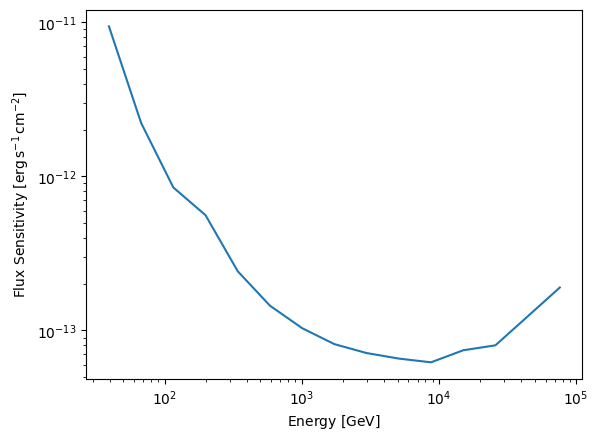

In [90]:
from feupy.visualization.sensitivity import plot_sensitivity_from_table

plot_sensitivity_from_table(table_sens)

In [91]:
table = analysis.table_sens
print(table[['e_ref', 'background', 'excess']])

 e_ref  background  excess
  GeV                     
------- ---------- -------
39.3143          2 4.01385
67.5164     2612.4  130.62
115.949    13705.6  685.28
199.125     8160.2  408.01
341.968     2663.2  133.16
587.278     1156.6 75.4414
1008.56      538.8 51.7863
1732.05      225.6 33.8372
2974.54       85.4 21.1748
5108.32       36.8 14.2167
8772.76         13  8.8219
15065.9         10 7.84971
25873.4        4.8 5.71854
44433.7        4.4 5.51384
76308.1          4  5.2996


In [92]:
table = analysis.datasets.info_table()
table

name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
obs-0,38704,9338.2,47.01590926166463,29365.799999999996,38693.00931879059,29367.99598124708,9325.013337543503,53862348.78905563,628287109922.3849,180000.0,180000.0,0.21502222222222223,0.1631433333333333,0.05187888888888889,15,15,wstat,10.406145217002791,146829,15.0,75.0,0.19999999999999998


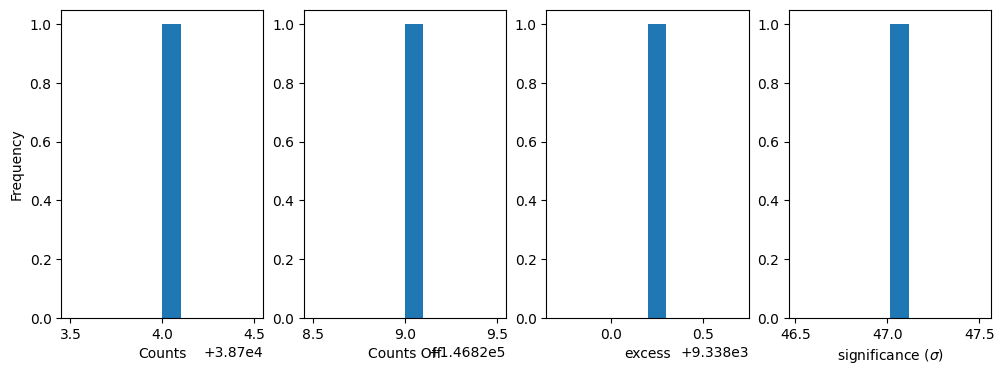

In [93]:
show_hist_counts(table)

In [94]:
analysis.flux_points.data.to_table()

INFO:gammapy.estimators.points.core:Inferred format: gadf-sed


e_ref,e_min,e_max,ref_dnde,ref_flux,ref_eflux,norm,norm_err,ts,sqrt_ts,npred,npred_excess,stat,stat_null,counts,success
GeV,GeV,GeV,1 / (TeV s cm2),1 / (s cm2),erg / (s cm2),,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[1],float32[1],float64,float64,float64[1],bool
39.31429989764608,30.000000000000004,51.52047254806851,3.4043819362528534e-09,7.478079216959248e-11,4.581970828244609e-12,1.5838082228738777,0.7347741258686874,9.32766362824495,3.054122399028066,6.999442132802648,5.799423,4.598636138553047e-08,9.327663674231312,7.0,True
67.51637695410695,51.52047254806851,88.47863638587606,8.156266199506266e-10,3.076817652479677e-11,3.2375955914951823e-12,1.0437410936693816,0.1671776898893701,41.353188114007935,6.4306444555742575,2980.9519005334673,369.5435,9.121140465140343e-07,41.35318902612198,2981.0,True
115.94918818030368,88.47863638587606,151.94870523363537,1.9540897455950896e-10,1.2659409711976745e-11,2.2876673830952275e-12,1.0015438573207274,0.03960430593121335,708.9701632675715,26.626493634490657,17338.999056611883,3585.199,0.0,708.9701632675715,17339.0,True
199.12523222047227,151.94870523363537,260.9489698901356,4.6816357392442875e-11,5.208649726984437e-12,1.6164532931245096e-12,1.0302728075248617,0.0492588412405035,487.8100462127477,22.086422213947365,10586.724665053494,2313.4817,8.279806934297085e-06,487.8100544925546,10587.0,True
341.9675353414204,260.9489698901356,448.1404746557164,1.1216328853051065e-11,2.143072433523337e-12,1.1421770787839662e-12,0.9268432109171482,0.05521201437862531,328.2166430003708,18.11675034326992,3765.022781548848,1100.426,1.573353074491024e-07,328.21664315770613,3765.0,True
587.2776338962768,448.1404746557164,769.6136340726085,2.68722386676101e-12,8.817562508636259e-13,8.070560930206785e-13,0.9878712155793904,0.058461553368424526,359.5560016026284,18.9619619660685,1912.9666870404158,781.56274,6.487389327958226e-07,359.5560022513673,1913.0,True
1008.5607071749256,769.6136340726085,1321.6952702285685,6.438088794200875e-13,3.6279412388261073e-13,5.702614326451517e-13,1.0358315190847716,0.0649372171718803,345.24912495195895,18.580880629075654,1102.7471080856371,555.322,6.37491320958361e-05,345.24918870109104,1103.0,True
1732.0508075688779,1321.6952702285685,2269.812162890764,1.5424463824807617e-13,1.4926979672084945e-13,4.029436173950921e-13,0.9532350082198934,0.07542939685600454,231.6548265884776,15.220211121678885,517.0077120004139,299.20837,1.2472810340113938e-07,231.6548267132057,517.0,True


### 4. Inspect Results
Here, we review the results of the spectrum analysis, including the fit parameters and computed flux points.

In [95]:
# Display the fit parameters
print("Fit Parameters:")
print(analysis.fit_result)

# Display the flux points
print("Flux Points:")
print(analysis.flux_points)

Fit Parameters:
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 44
	total stat : 10.41

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.

Flux Points:
FluxPointsDataset
-----------------

  Name                            : zll6BhPJ 

  Number of total flux points     : 15 
  Number of fit bins              : 15 

  Fit statistic type              : chi2
  Fit statistic value (-2 log(L)) : 12.51

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 2

  Component 0: SkyModel
  
    Name                      : source
    Datasets names            : None
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : 
    Temporal model type       : 
    Parameters:
      index                         :      2.642   +/-    0.02             


(<Axes: xlabel='Energy [$\\mathrm{GeV}$]', ylabel='e2dnde [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>,
 <Axes: xlabel='Energy [$\\mathrm{GeV}$]', ylabel='Residuals\n (data - model) / model'>)

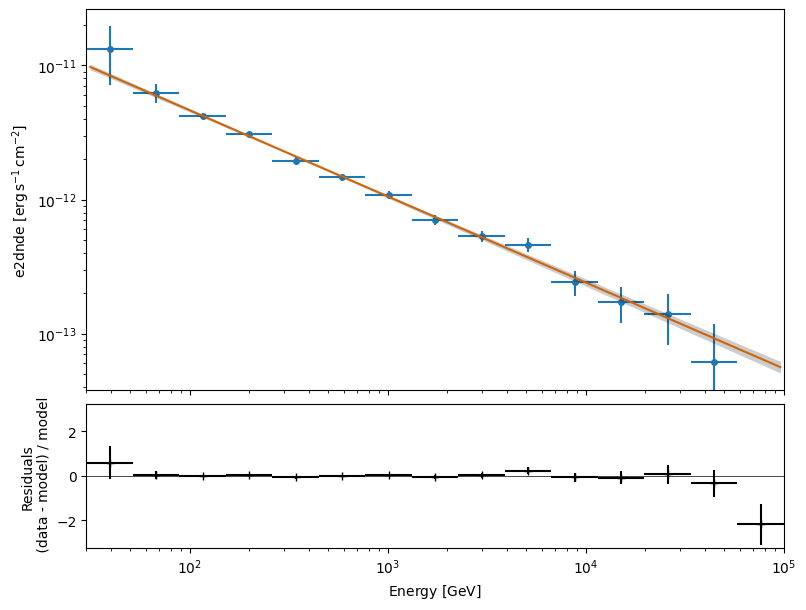

In [96]:
analysis.flux_points.plot_fit()

## 5. Summary

In this notebook, we:

1. Selected a source from the 3HWC catalog.
2. Configured and ran a 1D ON/OFF spectrum analysis using `AnalysisSpectrum`.
3. Printed and saved the fit results and flux points for further analysis.

This modular design
